# Exercise: Printers

**Module 7: Categorical Outcomes** | Lean Six Sigma Data Analytics

---

## The Scenario

Suppose you have two types of printers: **Printer AX-2** and **Printer AX-4**.

You would like to know if one of these produces prints of higher quality.

Quality is measured as **uniformity**, which is categorized into:
- Good
- Dubious
- Bad

This is determined by visual inspection.

**Question:** Does the type of printer affect the quality of prints?

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for printers analysis!')


Ready for printers analysis!


---

## Step 1: Identify Variables

Before doing anything, find your Y-variable and X-variable:

| Variable | Description | Type |
|----------|-------------|------|
| Quality (Uniformity) | Good, Dubious, or Bad | Categorical — **Y/CTQ** |
| Printer | AX-2 or AX-4 | Categorical — **X/Influence factor** |

Since **both variables are categorical**, we should perform a **chi-square test**.

In [2]:
def load_printers():
    """Load printers data in cross-tabulation format"""
    df = pd.read_excel(xlsx, sheet_name='Printers', skiprows=6, header=0, usecols=[0, 1, 2, 3])
    df.columns = ['Printer', 'Good', 'Dubious', 'Bad']
    df = df.dropna()
    df = df.set_index('Printer')
    return df.astype(int)

printers = load_printers()
print('DATA LOADED')
print('=' * 50)
print('\nCross-tabulation (already in correct format):')
print(printers)
print(f'\nTotal prints: {printers.values.sum()}')

DATA LOADED

Cross-tabulation (already in correct format):
         Good  Dubious  Bad
Printer                    
AX-4       10       13   17
AX-2       19       15    6

Total prints: 80


---

## Step 2: Chi-Square Analysis

Remember the steps of chi-square analysis:
1. Make a cross-tabulation (data is already in this format)
2. Perform main analysis and calculate p-value

**Hypotheses:**
- **H₀ (Null):** There is no relationship between the type of printer and the uniformity
- **H₁ (Alternative):** The type of printer influences the uniformity of the prints

In [3]:
# Perform Chi-Square Test
chi2, p_value, dof, expected = stats.chi2_contingency(printers)

print('CHI-SQUARE TEST')
print('=' * 50)
print(f'\nChi-Square Statistic: {chi2:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'P-Value: {p_value:.4f}')

CHI-SQUARE TEST

Chi-Square Statistic: 8.1968
Degrees of Freedom: 2
P-Value: 0.0166


In [4]:
# Display observed vs expected counts
expected_df = pd.DataFrame(expected, index=printers.index, columns=printers.columns)

print('OBSERVED COUNTS')
print('=' * 50)
print(printers)
print()
print('EXPECTED COUNTS')
print('=' * 50)
print('(If quality was unrelated to printer type)')
print(expected_df.round(2))

OBSERVED COUNTS
         Good  Dubious  Bad
Printer                    
AX-4       10       13   17
AX-2       19       15    6

EXPECTED COUNTS
(If quality was unrelated to printer type)
         Good  Dubious   Bad
Printer                     
AX-4     14.5     14.0  11.5
AX-2     14.5     14.0  11.5


In [5]:
print('UNDERSTANDING EXPECTED COUNTS')
print('=' * 50)
print()
print('The expected count is the number of prints we would expect')
print('if the two variables (printer and quality) are UNRELATED.')
print()
print('For example:')
print(f'  - AX-4 was expected to print {expected_df.loc["AX-4", "Good"]:.1f} good prints')
print(f'    but actually printed {printers.loc["AX-4", "Good"]} good prints')
print()
print(f'  - AX-4 was expected to print {expected_df.loc["AX-4", "Bad"]:.1f} bad prints')
print(f'    but actually printed {printers.loc["AX-4", "Bad"]} bad prints')

UNDERSTANDING EXPECTED COUNTS

The expected count is the number of prints we would expect
if the two variables (printer and quality) are UNRELATED.

For example:
  - AX-4 was expected to print 14.5 good prints
    but actually printed 10 good prints

  - AX-4 was expected to print 11.5 bad prints
    but actually printed 17 bad prints


In [6]:
print('INTERPRETATION')
print('=' * 50)
print(f'\nP-value: {p_value:.3f}')
print()

if p_value < 0.05:
    print('The p-value is SMALLER than 0.05.')
    print()
    print('This means the effect is STATISTICALLY SIGNIFICANT.')
    print('The alternative hypothesis can be supported.')
    print()
    print('The difference in quality of prints is NOT due to random fluctuations')
    print('and CAN be attributed to the printer.')
else:
    print('The p-value is larger than 0.05.')
    print('The effect is NOT statistically significant.')

INTERPRETATION

P-value: 0.017

The p-value is SMALLER than 0.05.

This means the effect is STATISTICALLY SIGNIFICANT.
The alternative hypothesis can be supported.

The difference in quality of prints is NOT due to random fluctuations
and CAN be attributed to the printer.


In [7]:
# Compare observed vs expected for each printer
print('PRINTER PERFORMANCE ANALYSIS')
print('=' * 50)
print()

for printer in printers.index:
    print(f'{printer}:')
    obs_good = printers.loc[printer, 'Good']
    exp_good = expected_df.loc[printer, 'Good']
    obs_bad = printers.loc[printer, 'Bad']
    exp_bad = expected_df.loc[printer, 'Bad']
    
    good_diff = obs_good - exp_good
    bad_diff = obs_bad - exp_bad
    
    print(f'  Good prints: {obs_good} observed vs {exp_good:.1f} expected ({good_diff:+.1f})')
    print(f'  Bad prints:  {obs_bad} observed vs {exp_bad:.1f} expected ({bad_diff:+.1f})')
    
    if good_diff > 0 and bad_diff < 0:
        print(f'  → {printer} performed BETTER than expected')
    elif good_diff < 0 and bad_diff > 0:
        print(f'  → {printer} performed WORSE than expected')
    print()

PRINTER PERFORMANCE ANALYSIS



AX-4:
  Good prints: 10 observed vs 14.5 expected (-4.5)
  Bad prints:  17 observed vs 11.5 expected (+5.5)
  → AX-4 performed WORSE than expected

AX-2:
  Good prints: 19 observed vs 14.5 expected (+4.5)
  Bad prints:  6 observed vs 11.5 expected (-5.5)
  → AX-2 performed BETTER than expected



---

## Visualization

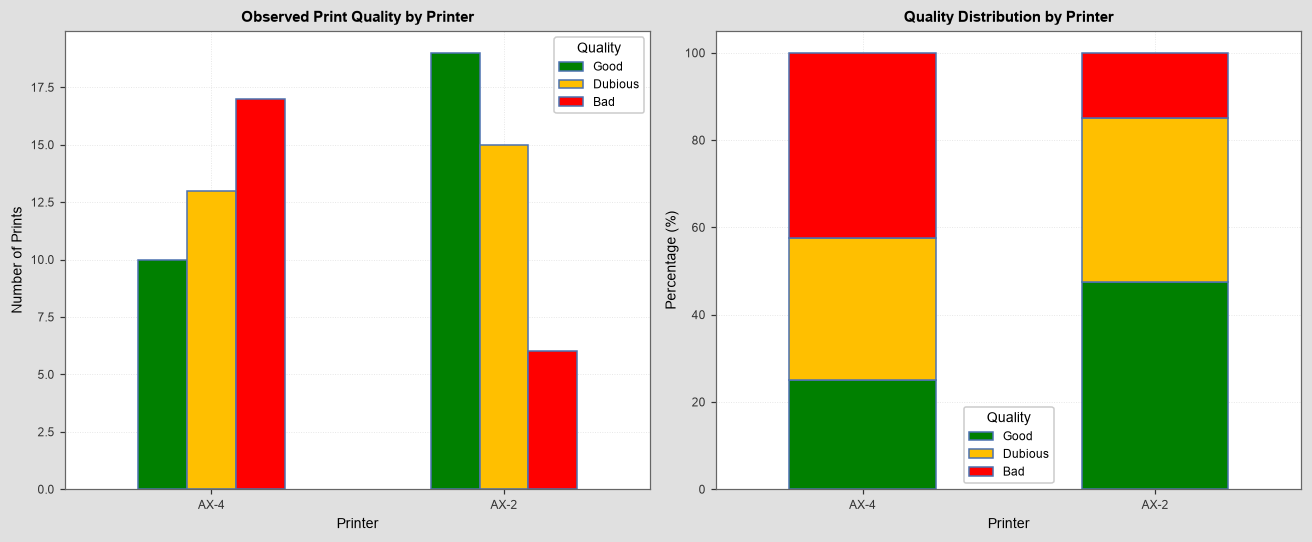

In [8]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Observed counts
printers.plot(kind='bar', ax=axes[0], edgecolor=ms.HIST_EDGE, color=['green', ms.GOLD, 'red'])
axes[0].set_xlabel('Printer')
axes[0].set_ylabel('Number of Prints')
axes[0].set_title('Observed Print Quality by Printer')
axes[0].legend(title='Quality')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Percentage distribution
pct = printers.div(printers.sum(axis=1), axis=0) * 100
pct.plot(kind='bar', stacked=True, ax=axes[1], edgecolor=ms.HIST_EDGE, color=['green', ms.GOLD, 'red'])
axes[1].set_xlabel('Printer')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Quality Distribution by Printer')
axes[1].legend(title='Quality')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

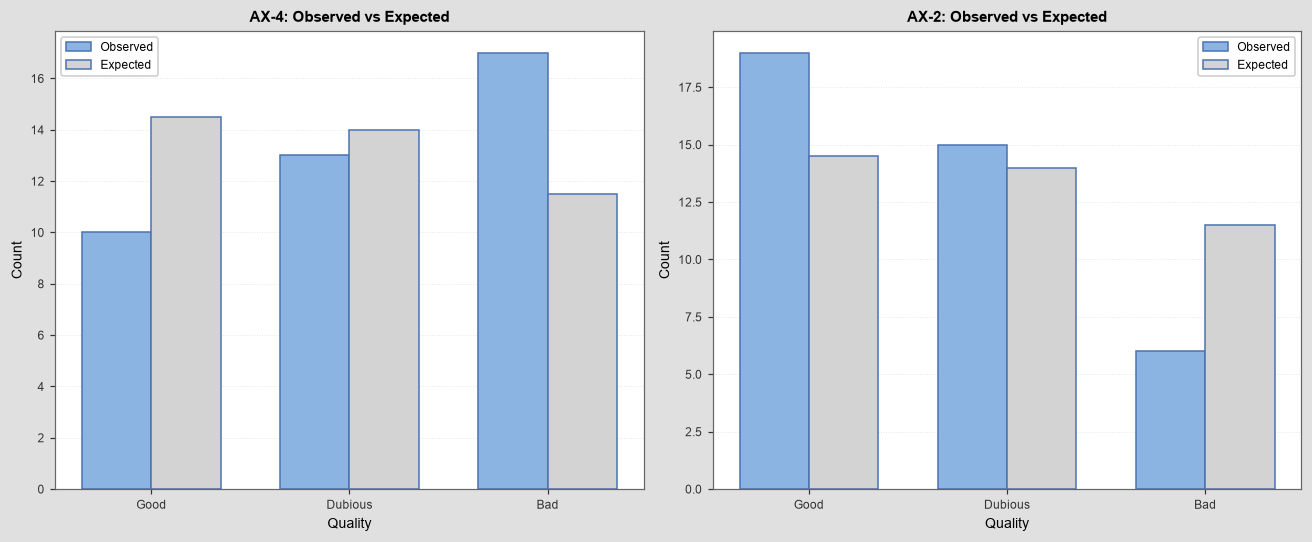

In [9]:
# Observed vs Expected comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(len(printers.columns))
width = 0.35

for idx, (ax, printer) in enumerate(zip(axes, printers.index)):
    obs = printers.loc[printer].values
    exp = expected_df.loc[printer].values
    
    bars1 = ax.bar(x - width/2, obs, width, label='Observed', color=ms.HIST_FILL, edgecolor=ms.HIST_EDGE)
    bars2 = ax.bar(x + width/2, exp, width, label='Expected', color='lightgray', edgecolor=ms.HIST_EDGE)
    
    ax.set_xlabel('Quality')
    ax.set_ylabel('Count')
    ax.set_title(f'{printer}: Observed vs Expected')
    ax.set_xticks(x)
    ax.set_xticklabels(printers.columns)
    ax.legend()

plt.tight_layout()
plt.show()

---

## Summary

In [10]:
print('FINAL ANSWER')
print('=' * 50)
print()
print(f'Chi-Square Analysis showed a p-value of {p_value:.3f}')
print()
print('This means we found a STATISTICALLY SIGNIFICANT relationship')
print('between printer and uniformity (quality).')
print()
print('Conclusion:')
print('  • Printer AX-2 performed BETTER than expected')
print('  • Printer AX-4 performed WORSE than expected')
print()
print('The type of printer DOES affect the quality of prints.')

FINAL ANSWER

Chi-Square Analysis showed a p-value of 0.017

This means we found a STATISTICALLY SIGNIFICANT relationship
between printer and uniformity (quality).

Conclusion:
  • Printer AX-2 performed BETTER than expected
  • Printer AX-4 performed WORSE than expected

The type of printer DOES affect the quality of prints.


---

## Key Takeaways

| Step | Action | Result |
|------|--------|--------|
| 1 | Identify variables | Y: Quality (categorical), X: Printer (categorical) → Chi-square |
| 2 | Cross-tabulation | Data already in correct format |
| 3 | Chi-square test | p-value < 0.05 → Significant relationship |
| 4 | Compare observed vs expected | AX-2 better, AX-4 worse than expected |

**Key Insight:** The expected counts tell us what we would see if there was NO relationship between variables. Comparing observed to expected reveals which categories are over- or under-performing.